In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# Quick start guide
- How to open the dataset
- Map view
- Station selection and visualization of time series
- time selection and visualization

In [2]:
PANGA = "https://zenodo.org/records/18510140/files/gnss_PANGA_2010_2025_5y_NA.nc?download=1"
SOPAC = "https://zenodo.org/records/18510140/files/gnss_SOPAC_2010_2025.nc?download=1"
UNR = "https://zenodo.org/records/18510140/files/gnss_unr_2010_2025_5y_NA.nc?download=1"

# pip install fsspec requests h5netcdf
ds = xr.open_dataset(
    "simplecache::" + UNR,
    engine="h5netcdf",
    backend_kwargs={"storage_options": {"simplecache": {"cache_storage": "./.cache"}}},
)
ds

<xarray.Dataset> Size: 159MB
Dimensions:        (station: 486, time: 5840)
Coordinates:
  * station        (station) <U4 8kB 'abby' 'abot' 'al2h' ... 'yonc' 'zse1'
    lat            (station) float64 4kB ...
    lon            (station) float64 4kB ...
    elev_m         (station) float64 4kB ...
  * time           (time) datetime64[ns] 47kB 2010-01-01 ... 2025-12-27
Data variables:
    dec_year       (station, time) float64 23MB ...
    east_m         (station, time) float64 23MB ...
    north_m        (station, time) float64 23MB ...
    up_m           (station, time) float64 23MB ...
    east_sigma_m   (station, time) float64 23MB ...
    north_sigma_m  (station, time) float64 23MB ...
    up_sigma_m     (station, time) float64 23MB ...

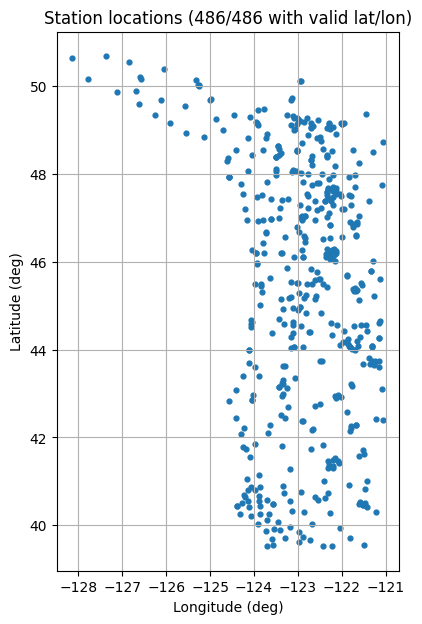

In [3]:
ds_plot = ds.where(ds.lon.notnull() & ds.lat.notnull(), drop=True)

n_total = ds.sizes["station"]
n_ok = ds_plot.sizes["station"]

plt.figure(figsize=(9, 7))
plt.scatter(ds_plot.lon, ds_plot.lat, s=12)
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title(f"Station locations ({n_ok}/{n_total} with valid lat/lon)")
plt.grid(True)
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

In [4]:
stat = ds.sel(station="albh")
stat

<xarray.Dataset> Size: 374kB
Dimensions:        (time: 5840)
Coordinates:
  * time           (time) datetime64[ns] 47kB 2010-01-01 ... 2025-12-27
    station        <U4 16B 'albh'
    lat            float64 8B 48.39
    lon            float64 8B -123.5
    elev_m         float64 8B ...
Data variables:
    dec_year       (time) float64 47kB ...
    east_m         (time) float64 47kB ...
    north_m        (time) float64 47kB ...
    up_m           (time) float64 47kB ...
    east_sigma_m   (time) float64 47kB ...
    north_sigma_m  (time) float64 47kB ...
    up_sigma_m     (time) float64 47kB ...

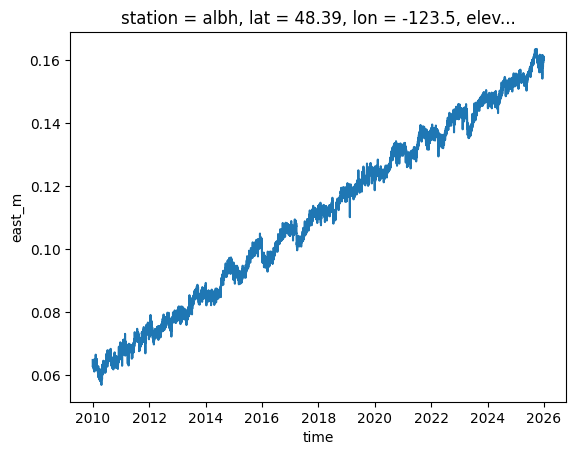

In [5]:
stat.east_m.plot()

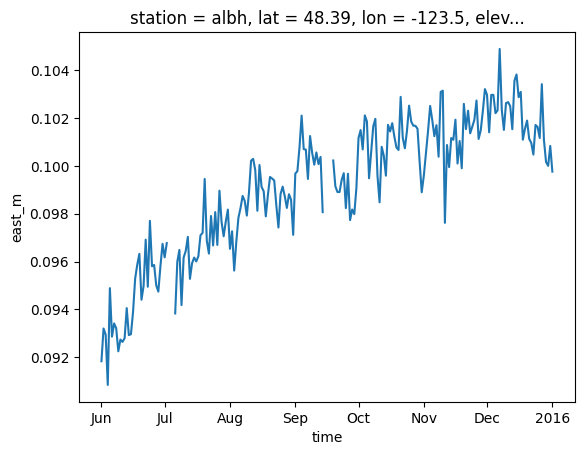

In [6]:
stat.sel(time=slice('2015-06-01', '2016-01-01')).east_m.plot()